In [3]:
pip install pdfplumber pandas duckdb pytesseract pillow --quiet

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pdfplumber

PDF_PATH = r"C:\Users\ADMIN\Desktop\data\The Basic Education Statistical Booklet 2020 (1).pdf"   # <-- replace with your actual path

with pdfplumber.open(PDF_PATH) as pdf:
    print("Number of pages:", len(pdf.pages))
    first_page_text = pdf.pages[0].extract_text()
    print(first_page_text[:500])

Number of pages: 154
REPUBLIC OF KENYA
MINISTRY OF EDUCATION
BASIC EDUCATION
STATISTICAL BOOKLET
2020
Jogoo House “B” Taifa Road P.O. Box 300400-00100 Nairobi.
Email us : info@education.go.ke · Call us : +254(0) 3318581


In [7]:
def classify_page(page, min_chars=20):
    text = page.extract_text() or ""
    return "text_layer" if len(text.strip()) >= min_chars else "scanned"

with pdfplumber.open(PDF_PATH) as pdf:
    classifications = [classify_page(page) for page in pdf.pages]

n_text = classifications.count("text_layer")
n_scanned = classifications.count("scanned")
print(f"text-layer pages: {n_text}")
print(f"scanned pages: {n_scanned}")

if n_scanned:
    scanned_page_numbers = [i+1 for i, c in enumerate(classifications) if c == "scanned"]
    print("Scanned page numbers:", scanned_page_numbers)

text-layer pages: 154
scanned pages: 0


In [8]:
with pdfplumber.open(PDF_PATH) as pdf:
    for i, page in enumerate(pdf.pages, start=1):
        text = page.extract_text() or ""
        if text.startswith("ANNEX"):
            print(i, text.splitlines()[0])

105 ANNEX I: PRE-PRIMARY LEVEL TABLES BY COUNTY
115 ANNEX II: PRIMARY LEVEL TABLES BY COUNTY
131 ANNEX III: SECONDARY LEVEL TABLES BY COUNTY
145 ANNEX IV: NATIONAL ASSESSMENTS AND EXAMINATIONS
148 ANNEX V: ADULT AND CONTINUING EDUCATION


In [9]:
with pdfplumber.open(PDF_PATH) as pdf:
    page = pdf.pages[104]  # page 105, but pdfplumber is 0-indexed
    tables = page.extract_tables()  # default settings
    print("Number of tables found:", len(tables))
    for t in tables:
        print("rows:", len(t))
        print(t[:5])

Number of tables found: 2
rows: 1
[['County', 'Public', 'Private', 'Total']]
rows: 1
[['National', '28505', '18147', '46652']]


In [10]:
table_settings = {
    "vertical_strategy": "text",
    "horizontal_strategy": "text",
    "snap_tolerance": 5,
    "intersection_tolerance": 5,
}

with pdfplumber.open(PDF_PATH) as pdf:
    page = pdf.pages[104]
    tables = page.extract_tables(table_settings)
    print("Number of tables found:", len(tables))
    print("Rows in first table:", len(tables[0]))
    for row in tables[0][:8]:
        print(row)
    

Number of tables found: 1
Rows in first table: 49
['County', 'Public', 'Private', 'Total']
['Mombasa', '93', '349', '442']
['Kwale', '857', '318', '1175']
['Kilifi', '778', '784', '1562']
['Tana River', '303', '64', '367']
['Lamu', '136', '55', '191']
['Taita Taveta', '314', '111', '425']
['Garissa', '287', '123', '410']


In [11]:
import pandas as pd

TABLE_PAGES = {
    "pre-primary": 105,
    "primary": 115,
    "secondary": 131,
}

NAME_FIXES = {
    "Nairobi City": "Nairobi",
    "Murang’a": "Murang'a",  # curly apostrophe -> straight
}

def clean_county_name(name):
    name = name.strip()
    return NAME_FIXES.get(name, name)

def parse_int(value):
    value = value.replace(",", "").strip()
    if not value or value == "-":
        return None
    try:
        return int(value)
    except ValueError:
        return None

def extract_level_table(pdf, page_number, level):
    page = pdf.pages[page_number - 1]
    rows = page.extract_table(table_settings)
    header, *data_rows = rows
    assert [h.strip() for h in header] == ["County", "Public", "Private", "Total"]

    records = []
    for row in data_rows:
        county_raw, public, private, total = row
        county = clean_county_name(county_raw)
        if county.lower() == "national":
            continue
        for sector, raw_value in [("public", public), ("private", private), ("total", total)]:
            count = parse_int(raw_value)
            if count is not None:
                records.append({"county": county, "level": level, "sector": sector, "count": count})
    return pd.DataFrame.from_records(records)

with pdfplumber.open(PDF_PATH) as pdf:
    frames = [extract_level_table(pdf, page, level) for level, page in TABLE_PAGES.items()]

df = pd.concat(frames, ignore_index=True)
print(df.shape)
df.head(10)

(423, 4)


,county,level,sector,count
0,Mombasa,pre-primary,public,93
1,Mombasa,pre-primary,private,349
2,Mombasa,pre-primary,total,442
3,Kwale,pre-primary,public,857
4,Kwale,pre-primary,private,318
5,Kwale,pre-primary,total,1175
6,Kilifi,pre-primary,public,778
7,Kilifi,pre-primary,private,784
8,Kilifi,pre-primary,total,1562
9,Tana River,pre-primary,public,303


In [12]:
print("Shape:", df.shape)
print("Unique counties:", df['county'].nunique())

# Sanity check: public + private should equal total, for every county/level
wide = df.pivot_table(index=["county", "level"], columns="sector", values="count").reset_index()
mismatches = wide[wide["public"] + wide["private"] != wide["total"]]

if mismatches.empty:
    print("✓ All public + private = total")
else:
    print("✗ Mismatches found:")
    print(mismatches)

Shape: (423, 4)
Unique counties: 47
✓ All public + private = total


In [13]:
df.to_csv("schools_per_county.csv", index=False)
print("Saved.")

Saved.


In [14]:
import duckdb

con = duckdb.connect("kenya_education.duckdb")

con.execute("""
    CREATE TABLE IF NOT EXISTS school_counts (
        county  VARCHAR NOT NULL,
        level   VARCHAR NOT NULL CHECK (level IN ('pre-primary', 'primary', 'secondary')),
        sector  VARCHAR NOT NULL CHECK (sector IN ('public', 'private', 'total')),
        count   INTEGER NOT NULL
    )
""")

con.execute("DELETE FROM school_counts")  # makes re-running this cell safe
con.execute("""
    INSERT INTO school_counts
    SELECT county, level, sector, count
    FROM read_csv_auto('schools_per_county.csv')
""")

n = con.execute("SELECT COUNT(*) FROM school_counts").fetchone()[0]
print(f"Loaded {n} rows")

Loaded 423 rows


In [15]:
con.execute("""
    SELECT county,
           SUM(count) FILTER (WHERE level = 'primary' AND sector = 'total') AS primary_schools
    FROM school_counts
    GROUP BY county
    ORDER BY primary_schools DESC
    LIMIT 5
""").df()

,county,primary_schools
0,Kitui,1523.0
1,Machakos,1265.0
2,Kakamega,1128.0
3,Homa Bay,1053.0
4,Makueni,1017.0


In [16]:
con.execute("INSTALL spatial")
con.execute("LOAD spatial")
print("Spatial extension loaded")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Spatial extension loaded


In [18]:
GEOJSON_PATH = r"C:\Users\ADMIN\Desktop\data\geoBoundaries-KEN-ADM1.geojson"  # adjust path if needed

con.execute(f"""
    CREATE OR REPLACE TABLE counties_raw AS
    SELECT * FROM ST_Read('{GEOJSON_PATH}')
""")

con.execute("DESCRIBE counties_raw").df()

,column_name,column_type,null,key,default,extra
0,OGC_FID,BIGINT,YES,None,None,None
1,shapeName,VARCHAR,YES,None,None,None
2,shapeISO,VARCHAR,YES,None,None,None
3,shapeID,VARCHAR,YES,None,None,None
4,shapeGroup,VARCHAR,YES,None,None,None
5,shapeType,VARCHAR,YES,None,None,None
6,geom,GEOMETRY('EPSG:4326'),YES,None,None,None


In [19]:
con.execute("""
    CREATE TABLE IF NOT EXISTS counties (
        county  VARCHAR PRIMARY KEY,
        geom    GEOMETRY
    )
""")

con.execute("DELETE FROM counties")
con.execute("""
    INSERT INTO counties
    SELECT shapeName AS county, geom
    FROM counties_raw
""")

# Now the real test: does every county in our stats have a matching geometry?
unmatched = con.execute("""
    SELECT DISTINCT s.county
    FROM school_counts s
    LEFT JOIN counties c USING (county)
    WHERE c.county IS NULL
""").df()

print("Unmatched counties:", len(unmatched))
unmatched

Unmatched counties: 2


,county
0,Tharaka Nithi
1,Elgeyo Marakwet


In [21]:
con.execute("""
    SELECT county FROM counties
    WHERE county ILIKE '%tharaka%' OR county ILIKE '%elgeyo%' OR county ILIKE '%marakwet%'
""").df()

,county
0,Elgeyo-Marakwet
1,Tharaka


In [22]:
NAME_FIXES = {
    "Elgeyo-Marakwet": "Elgeyo Marakwet",
    "Tharaka": "Tharaka Nithi",
}

for wrong, right in NAME_FIXES.items():
    con.execute("UPDATE counties SET county = ? WHERE county = ?", [right, wrong])

# Re-run the unmatched check
unmatched = con.execute("""
    SELECT DISTINCT s.county
    FROM school_counts s
    LEFT JOIN counties c USING (county)
    WHERE c.county IS NULL
""").df()

print("Unmatched counties:", len(unmatched))
unmatched

Unmatched counties: 0


,county


In [24]:
con.execute("""
    COPY (
        SELECT
            c.county,
            CAST(stats.pre_primary_total AS INTEGER) AS pre_primary_total,
            CAST(stats.primary_total AS INTEGER) AS primary_total,
            CAST(stats.secondary_total AS INTEGER) AS secondary_total,
            c.geom
        FROM counties c
        JOIN (
            SELECT
                county,
                SUM(count) FILTER (WHERE level = 'pre-primary' AND sector = 'total') AS pre_primary_total,
                SUM(count) FILTER (WHERE level = 'primary' AND sector = 'total') AS primary_total,
                SUM(count) FILTER (WHERE level = 'secondary' AND sector = 'total') AS secondary_total
            FROM school_counts
            GROUP BY county
        ) stats USING (county)
    ) TO 'county_education_map.geojson' WITH (FORMAT GDAL, DRIVER 'GeoJSON')
""")

print("Exported county_education_map.geojson")

Exported county_education_map.geojson


In [25]:
import json

with open("county_education_map.geojson") as f:
    geo = json.load(f)

print("Feature count:", len(geo["features"]))
print("Sample feature properties:", geo["features"][0]["properties"])

Feature count: 47
Sample feature properties: {'county': 'Taita Taveta', 'pre_primary_total': 425, 'primary_total': 278, 'secondary_total': 94}


In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("county_education_map.geojson")
gdf.head()

,county,pre_primary_total,primary_total,secondary_total,geometry
0,Taita Taveta,425,278,94,"POLYGON ((39.07511 -3.04114, 39.07503 -3.04111..."
1,Makueni,1472,1017,407,"POLYGON ((37.75332 -1.56638, 37.75275 -1.56655..."
2,Kisumu,1207,834,250,"POLYGON ((34.74707 -0.02473, 34.7458 -0.02473,..."
3,Isiolo,249,160,35,"POLYGON ((37.94529 1.26288, 37.94816 1.19432, ..."
4,Turkana,942,471,61,"POLYGON ((36.05061 4.45622, 35.94395 4.54803, ..."


In [29]:
pip install geopandas matplotlib folium mapclassify --quiet

Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.5 which is incompatible.
streamlit 1.45.1 requires pillow<12,>=7.1.0, but you have pillow 12.3.0 which is incompatible.


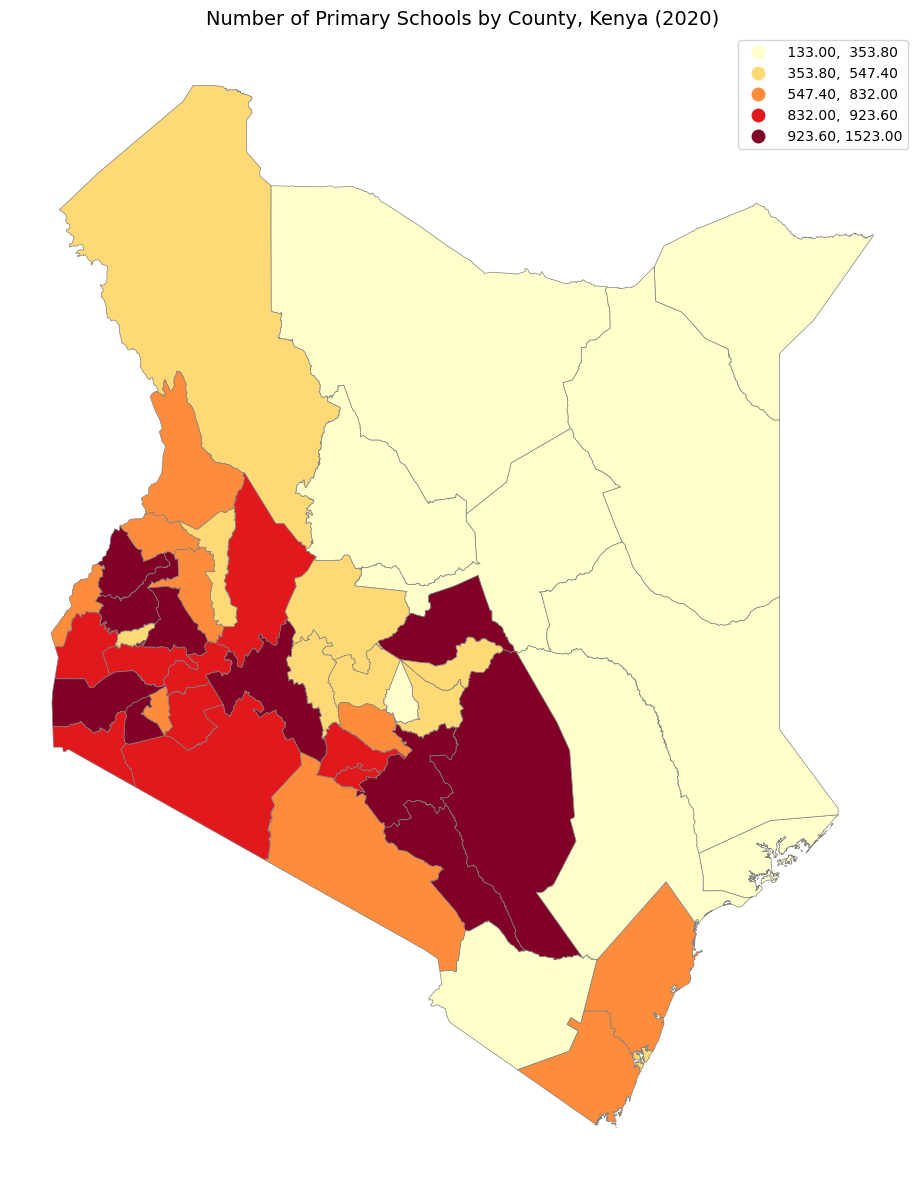

In [30]:
fig, ax = plt.subplots(figsize=(10, 12))

gdf.plot(
    column="primary_total",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    scheme="quantiles",   # from mapclassify — buckets counties into color bins by rank
    k=5,                  # number of color buckets
    ax=ax,
)

ax.set_title("Number of Primary Schools by County, Kenya (2020)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("primary_schools_choropleth.png", dpi=200)
plt.show()